# Notebook 1 — Exploratory Data Analysis

## Environment Setup and Configuration

This section prepares the environment required for data processing and exploratory analysis. Core libraries for data handling, visualisation, and text processing are imported to support subsequent stages of the pipeline.

Project-specific parameters are loaded from a central configuration file to ensure consistency and avoid hardcoding. Global plotting settings are defined to maintain uniform visual style across all figures.

Finally, a dedicated directory is created to store EDA outputs, ensuring that all generated visualisations are organised and reproducible.

In [1]:
# System path configured for project-level imports
import sys, os
sys.path.insert(0, os.path.abspath('..'))

# Core libraries for data handling and numerical operations
import pandas as pd
import numpy as np
import re

# Visualisation stack for plotting and formatting
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Utilities for text analysis and feature extraction
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

# Warnings suppressed for cleaner notebook output
import warnings
warnings.filterwarnings('ignore')

# Project configuration parameters and paths
from config import (
    RAW_CSV, VISUALISATION_DIR, MAX_LENGTH,
    WORDCLOUD_MAX, TOP_N_NGRAMS,
    NEGATION_CUES, INTENSIFIERS,
)

# Global plotting configuration for consistent styling
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': ":"
})

# Colour palette aligned with class labels
CLASS_PALETTE = {
    'suicide': '#C1121F',
    'non-suicide': '#0077B6'
}

# Output directory for EDA visualisations
EDA_DIR = VISUALISATION_DIR / 'eda'
os.makedirs(EDA_DIR, exist_ok=True)

## Dataset Loading and Initial Cleaning

This section prepares the dataset for analysis by ensuring a consistent and usable structure. The data is read from the raw source, followed by minor adjustments to column naming for uniformity across the pipeline.

Rows with missing values in essential fields are removed to maintain data integrity. The index is then reset to reflect the cleaned dataset.

A brief inspection is performed to verify the dataset shape and available class labels before proceeding to further analysis.

In [2]:
# Dataset loaded from source file
df = pd.read_csv(RAW_CSV, index_col=0)

# Column names cleaned to remove extra whitespace
df.columns = df.columns.str.strip()

# Target column aligned with pipeline naming convention
df.rename(columns={'class': 'label'}, inplace=True)

# Rows with missing text or labels filtered out
df.dropna(subset=['text', 'label'], inplace=True)

# Index reset after cleaning
df.reset_index(drop=True, inplace=True)

# Quick dataset overview
print(f'Shape: {df.shape}')
print(f'Columns: {df["label"].unique().tolist()}')

# Preview of processed dataset
df.head()

Shape: (232074, 2)
Columns: ['suicide', 'non-suicide']


,text,label
0,Ex Wife Threatening SuicideRecently I left my ...,suicide
1,Am I weird I don't get affected by compliments...,non-suicide
2,Finally 2020 is almost over... So I can never ...,non-suicide
3,i need helpjust help me im crying so hard,suicide
4,"I’m so lostHello, my name is Adam (16) and I’v...",suicide


## Class Distribution Summary

This section quantifies the distribution of classes within the dataset to provide a numerical overview of class balance. Both absolute counts and relative percentages are computed to capture the dataset composition from complementary perspectives.

The results offer a concise summary of how instances are distributed across classes, which is useful for validating assumptions about balance before model development.

In [3]:
# Class frequencies and percentage share
counts = df['label'].value_counts()
pcts = counts / counts.sum() * 100

# Formatted display of class distribution
for cls in counts.index:
    print(f' {cls:<15} {counts[cls]:>6,} ({pcts[cls]:.1f}%)')

 suicide         116,037 (50.0%)
 non-suicide     116,037 (50.0%)


## Visual Analysis of Class Balance

This section presents a visual assessment of class distribution to complement the numerical summary. Both absolute frequencies and relative proportions are visualised to provide a clearer understanding of dataset composition.

A bar chart illustrates the count of instances per class, while a pie chart highlights their percentage share. This combined view helps identify any imbalance patterns that may influence model training or evaluation.

The visual evidence indicates that the dataset is reasonably balanced, suggesting that additional corrective measures such as class weighting are not immediately necessary.

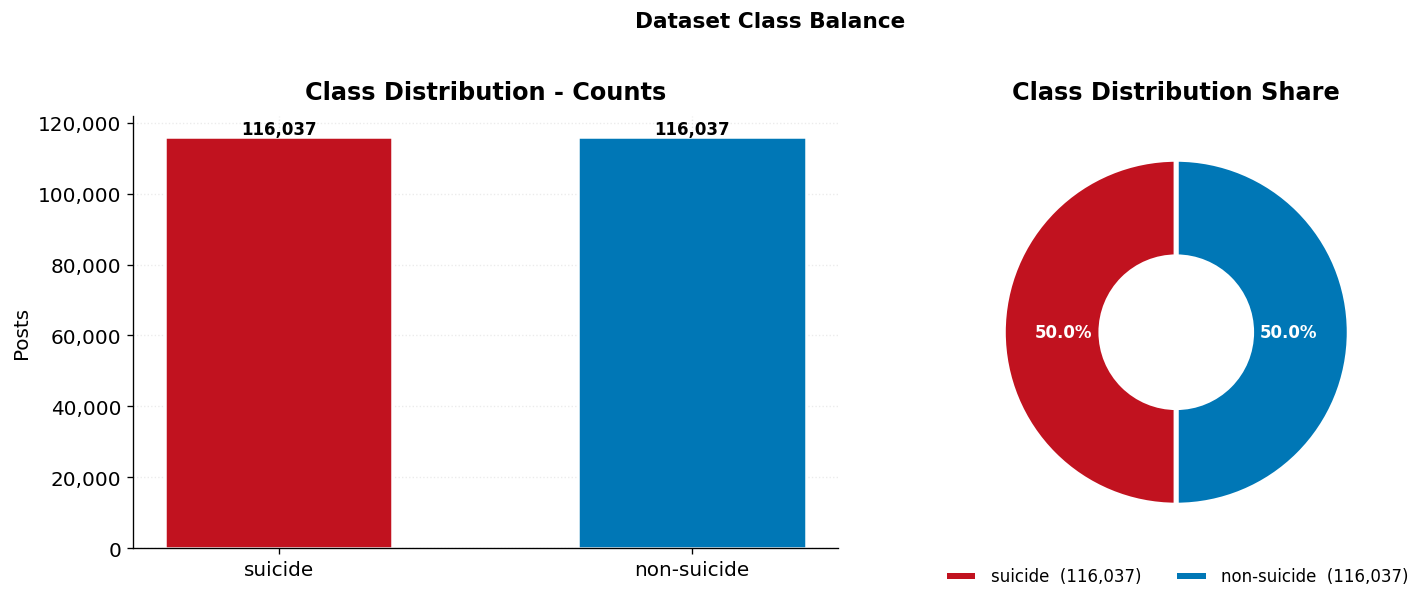

Observation: Dataset is roughly balanced — minimal class weighting needed.


In [4]:
# Figure layout with two panels
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Class counts visualised as bar chart
bars = axes[0].bar(
    counts.index,
    counts.values,
    color=[CLASS_PALETTE[c] for c in counts.index],
    edgecolor='white',
    linewidth=1.5,
    width=0.55
)

# Value labels added above bars
for bar, val in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 800,
        f'{val:,}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )
axes[0].set_title('Class Distribution - Counts', fontweight='bold', pad=10)
axes[0].set_ylabel('Posts')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
axes[0].set_axisbelow(True)

# Percentage distribution visualised using pie chart
wedge_props = {'edgecolor': 'white', 'linewidth': 3}
wedges, texts, autotexts = axes[1].pie(
    counts.values,
    labels=None,                  
    colors=[CLASS_PALETTE[c] for c in counts.index],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=wedge_props,
    pctdistance=0.65,             
    labeldistance=1.15            
)

# Percentage labels styled for clarity
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(10)
    at.set_color('white')         

# Donut-style centre added
centre = plt.Circle((0, 0), 0.45, fc='white')
axes[1].add_artist(centre)

# Clean legend outside the donut instead of crowded slice labels
axes[1].legend(
    wedges,
    [f'{cls}  ({cnt:,})' for cls, cnt in zip(counts.index, counts.values)],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    framealpha=0.0,
    fontsize=10
)

axes[1].set_title('Class Distribution Share', fontweight='bold', pad=10)

# Layout adjustments and figure export
plt.suptitle('Dataset Class Balance', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(
    EDA_DIR / 'class_distribution.png',
    bbox_inches='tight'
)
plt.show()

# Observation from visual analysis
print('Observation: Dataset is roughly balanced — minimal class weighting needed.')

## Text Length Feature Analysis

This section derives basic textual features to characterise the structural properties of the dataset. Features such as character length, word count, and sentence count provide insights into the complexity and verbosity of the text.

These features are computed directly from the raw text and then summarised for each class. Group-wise descriptive statistics allow comparison of typical text lengths and variation across classes.

Such analysis helps identify whether certain classes exhibit systematically longer or more complex text patterns, which may influence model behaviour.

In [5]:
# Text-level features derived from raw content
df['char_len'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()
df['sent_count'] = df['text'].str.count(r'[.!?]') + 1

# Summary statistics computed per class
summary = df.groupby('label')[
    ['char_len', 'word_count', 'sent_count']
].describe().round(1)
print(summary)

             char_len                                                      \
                count    mean     std  min    25%    50%     75%      max   
label                                                                       
non-suicide  116037.0   329.2   806.4  8.0   99.0  165.0   320.0  40106.0   
suicide      116037.0  1050.1  1328.2  3.0  310.0  653.0  1294.0  40297.0   

            word_count         ...                sent_count                   \
                 count   mean  ...    75%     max      count  mean   std  min   
label                          ...                                              
non-suicide   116037.0   61.2  ...   60.0  8220.0   116037.0   5.5  60.8  1.0   
suicide       116037.0  202.7  ...  251.0  9684.0   116037.0  15.8  21.1  1.0   

                                       
             25%   50%   75%      max  
label                                  
non-suicide  1.0   3.0   5.0  10673.0  
suicide      5.0  10.0  19.0   1938.0  

[2 rows

## Distribution of Textual Features

This section visualises the distribution of key text-derived features to better understand structural patterns within the dataset. Kernel Density Estimation (KDE) plots are used to capture the shape and spread of each feature across classes.

To reduce the influence of extreme values, each feature is clipped at the 99th percentile before plotting. This ensures that the visualisations remain interpretable and are not distorted by outliers.

Comparing these distributions across classes provides insight into whether differences in text length or sentence structure may act as discriminative signals for modelling.

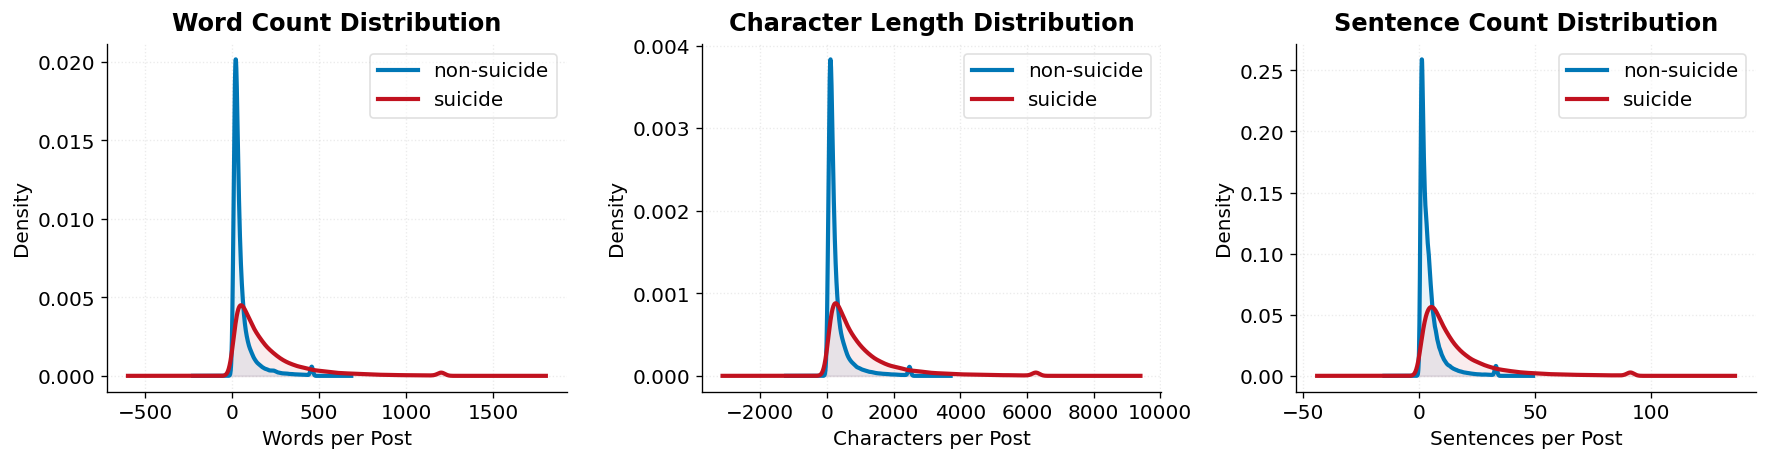

In [6]:
# Subplot grid prepared for feature-wise distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Feature configuration: column, title, axis label
features = [
    ('word_count', 'Word Count Distribution', 'Words per Post'),
    ('char_len', 'Character Length Distribution', 'Characters per Post'),
    ('sent_count', 'Sentence Count Distribution', 'Sentences per Post'),
]

# KDE plots for each feature across classes
for ax, (col, title, xlabel) in zip(axes, features):
    for label, grp in df.groupby('label'):
        clip_val = grp[col].quantile(0.99)
        grp[col].clip(upper=clip_val).plot.kde(
            ax=ax,
            label=label,
            color=CLASS_PALETTE[label],
            linewidth=2.5
        )

    for line in ax.lines:
        ax.fill_between(
            line.get_xdata(),
            line.get_ydata(),
            alpha=0.08,
            color=line.get_color()
        )

    ax.set_title(title, fontweight='bold', pad=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend(framealpha=0.6)

# Layout adjustment and figure saved
plt.tight_layout()
plt.savefig(
    EDA_DIR / 'text_length_distribution.png',
    bbox_inches='tight'
)
plt.show()

## Word Count Distribution by Class

This section provides a comparative view of word count distributions across classes using box plots. Unlike density plots, box plots summarise the distribution through key statistics such as median, quartiles, and variability.

To minimise the impact of extreme values, word counts are clipped at the 99th percentile prior to visualisation. This allows for a more stable comparison of central tendencies and spread across classes.

The resulting plot highlights differences in text length characteristics, which may serve as useful signals during model training.

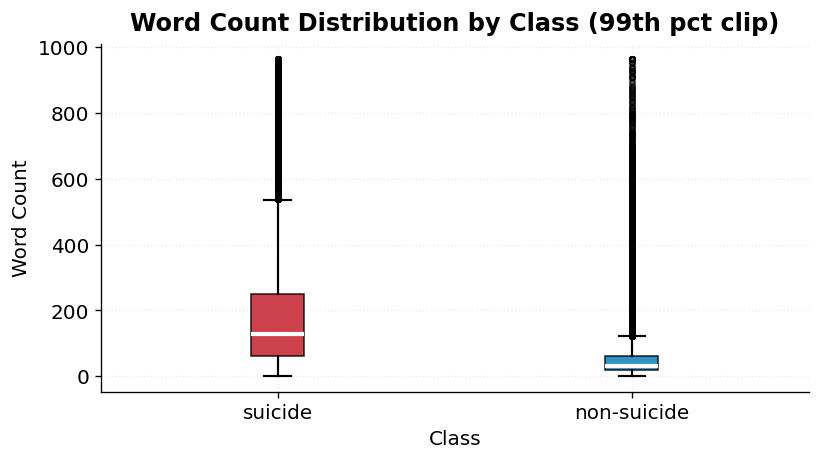

In [7]:
# Figure setup for box plot
fig, ax = plt.subplots(figsize=(7, 4))

# Word count data grouped by class with upper clipping
data_by_class = [
    df[df['label'] == label]['word_count'].clip(
        upper=df['word_count'].quantile(0.99)
    )
    for label in counts.index
]

# Box plot construction
bp = ax.boxplot(
    data_by_class,
    labels=counts.index,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2.5),
    whiskerprops=dict(linewidth=1.3),
    capprops=dict(linewidth=1.3),
    flierprops=dict(marker='o', markersize=3, alpha=0.3)
)

# Box colours aligned with class palette
for patch, label in zip(bp['boxes'], counts.index):
    patch.set_facecolor(CLASS_PALETTE[label])
    patch.set_alpha(0.8)

ax.set_title('Word Count Distribution by Class (99th pct clip)', fontweight='bold', pad=8)
ax.set_ylabel('Word Count')
ax.set_xlabel('Class')

# Layout adjustment and figure saved
plt.tight_layout()
plt.savefig(
    EDA_DIR / 'wordcount_boxplot.png',
    bbox_inches='tight'
)
plt.show()

## Truncation Analysis

This section evaluates the extent to which input sequences may be truncated during model training. Word count is used as a proxy for token length to estimate how many posts exceed the predefined maximum sequence length.

The proportion of such instances is computed to assess potential information loss. A histogram of word counts is also presented, with the truncation threshold highlighted for reference.

This analysis helps determine whether the chosen maximum length is appropriate or requires adjustment to better capture the underlying text distribution.

Posts exceeding MAX_LENGTH=128: 29.7%


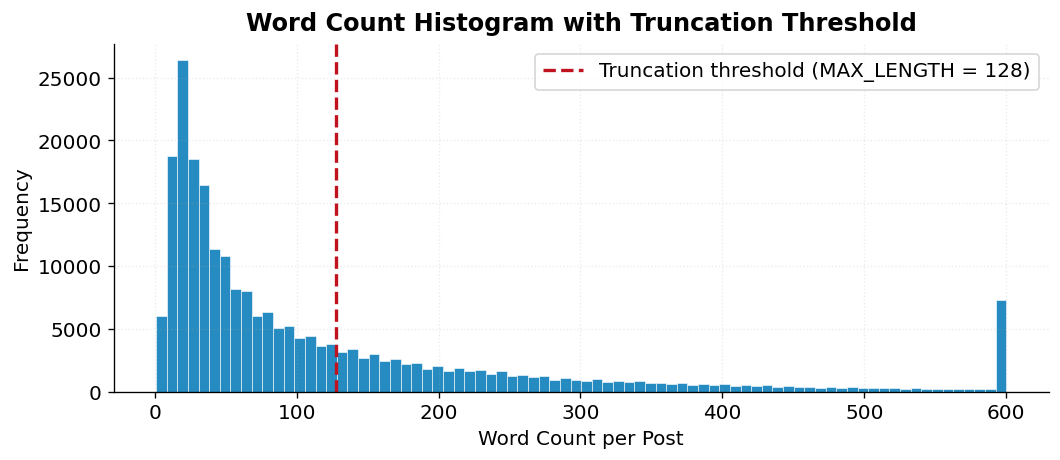

In [8]:
# Proportion of posts exceeding maximum length
pct_truncated = (df['word_count'] > MAX_LENGTH).mean() * 100
print(f'Posts exceeding MAX_LENGTH={MAX_LENGTH}: {pct_truncated:.1f}%')

# Histogram of word count distribution
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(
    df['word_count'].clip(upper=600),
    bins=80,
    color='#0077B6',
    edgecolor='white',
    linewidth=0.4,
    alpha=0.85
)

# Truncation threshold indicated on plot
ax.axvline(
    MAX_LENGTH,
    color='#C1121F',
    linewidth=2,
    linestyle='--',
    label=f'Truncation threshold (MAX_LENGTH = {MAX_LENGTH})'
)

ax.set_xlabel('Word Count per Post')
ax.set_ylabel('Frequency')
ax.set_title('Word Count Histogram with Truncation Threshold', fontweight='bold', pad=8)
ax.legend()

# Layout adjustment and figure saved
plt.tight_layout()
plt.savefig(
    EDA_DIR / 'truncation_threshold.png',
    bbox_inches='tight'
)
plt.show()

## Word Cloud Visualisation

This section explores the most prominent terms within each class using word clouds. These visualisations provide an intuitive overview of frequently occurring words and highlight differences in vocabulary usage across classes.

A lightweight text cleaning step is applied to remove URLs and punctuation while preserving the overall content. The cleaned text is then aggregated per class to construct a corpus for visualisation.

The resulting word clouds emphasise dominant terms, offering qualitative insight into thematic patterns present in each class.

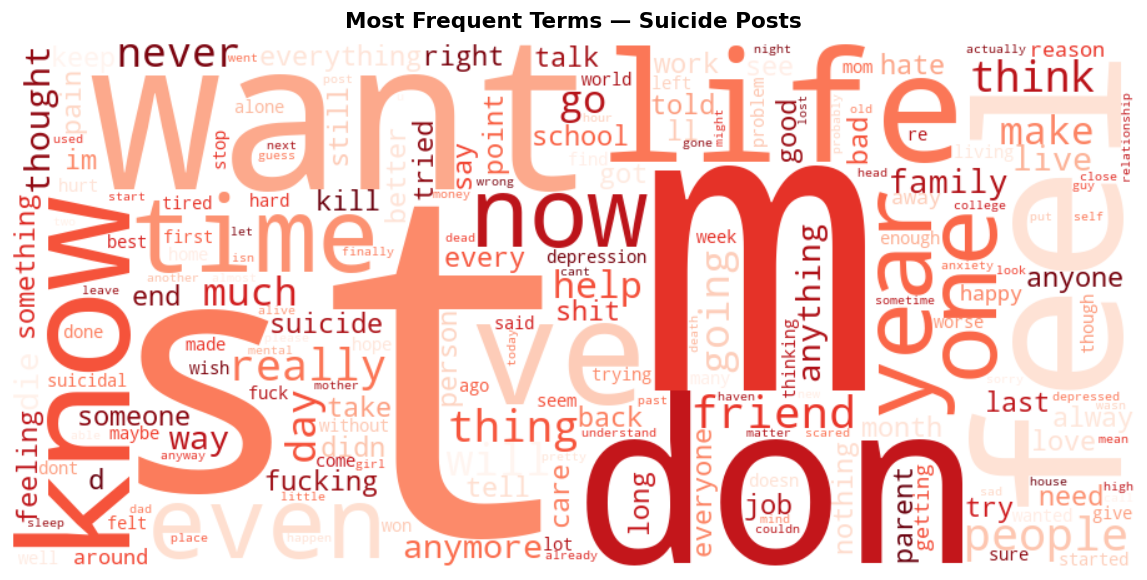

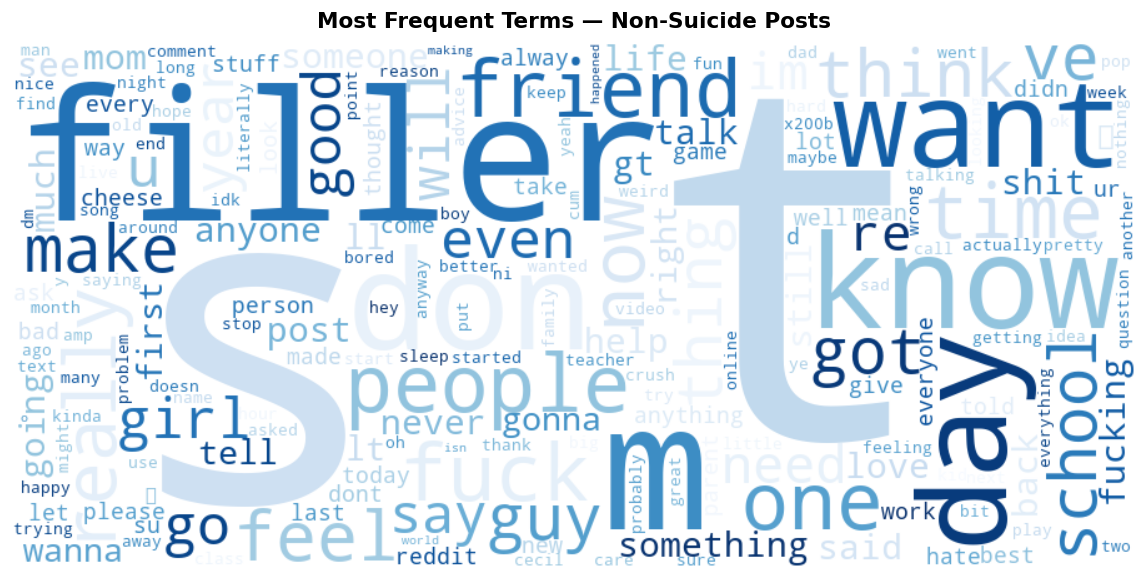

In [9]:
# Lightweight text cleaning for visualisation
def simple_clean(text):
    text = re.sub(r'http\S+', '', str(text))
    text = re.sub(r'[^\w\s]', ' ', text)
    return text.lower()

# Word clouds generated separately for each class
for label in ['suicide', 'non-suicide']:
    corpus = ' '.join(
        df[df['label'] == label]['text'].apply(simple_clean)
    )

    wc = WordCloud(
        width=900,
        height=420,
        background_color='white',
        colormap='Reds' if label == 'suicide' else 'Blues',
        max_words=WORDCLOUD_MAX,
        collocations=False,
        prefer_horizontal=0.9
    ).generate(corpus)

    # Visualisation of generated word cloud
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(
        f'Most Frequent Terms — {label.title()} Posts',
        fontweight='bold',
        fontsize=13,
        pad=10
    )

    # Layout adjustment and figure saved
    plt.tight_layout()
    plt.savefig(
        EDA_DIR / f'wordcloud_{label.replace("-", "_")}.png',
        bbox_inches='tight'
    )
    plt.show()

## N-gram Frequency Analysis

This section examines frequently occurring word patterns using n-gram analysis. Both unigrams and bigrams are extracted to capture individual terms as well as short contextual phrases.

A vectorisation approach is used to compute frequency counts across the corpus for each class. The most frequent n-grams are then identified and visualised to highlight dominant linguistic patterns.

Comparing these patterns across classes provides insight into distinguishing vocabulary and recurring expressions that may contribute to model performance.

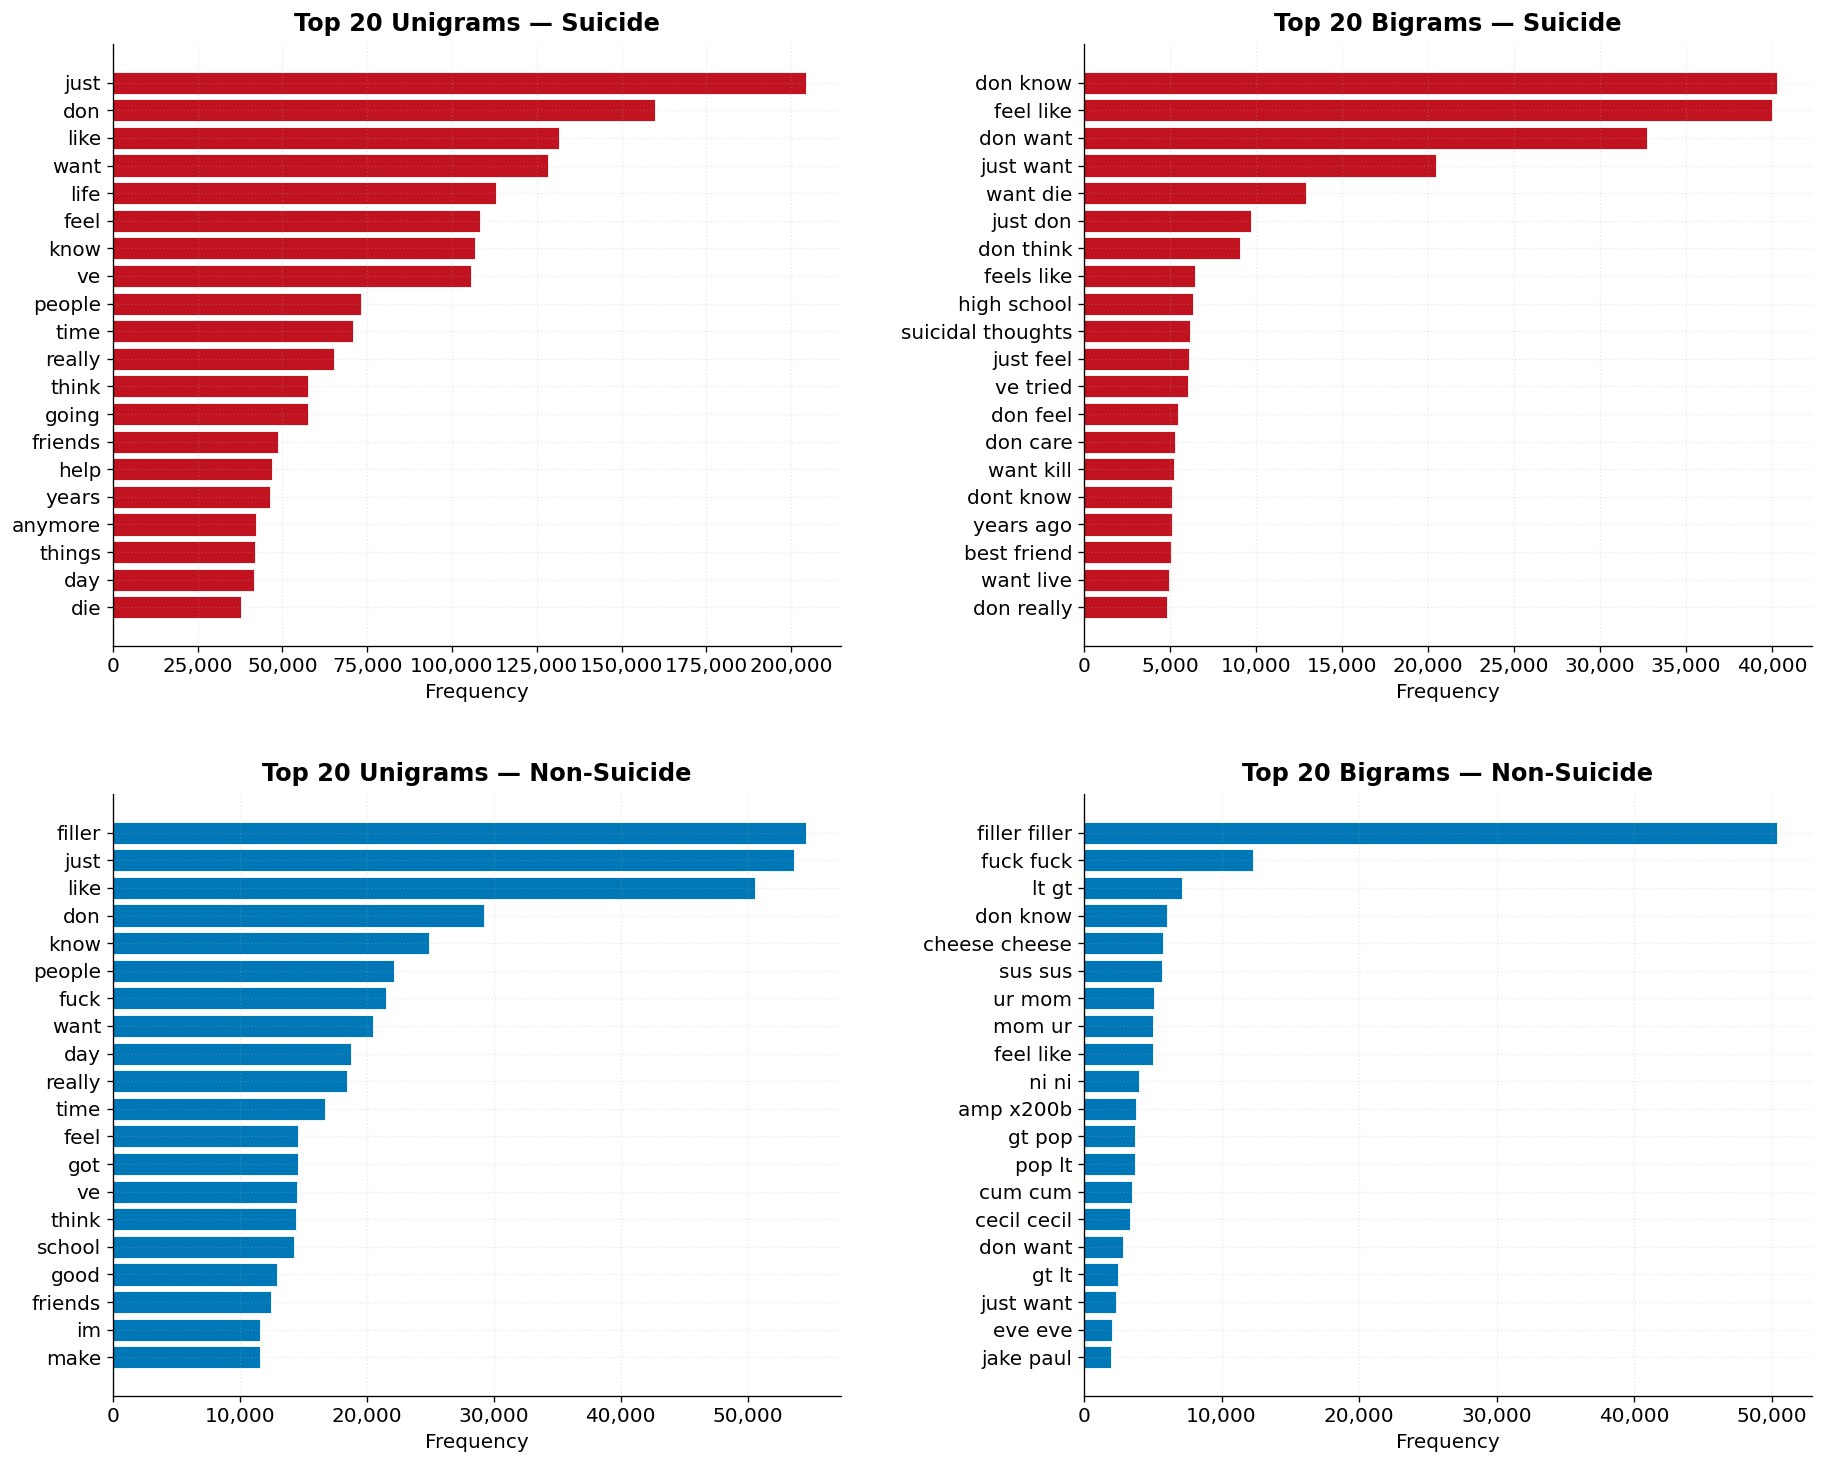

In [10]:
# Function to plot top n-grams
def plot_TOP_N_NGRAMS(corpus, n: int, top_k: int, ax, title: str, color: str):
    vec = CountVectorizer(
        ngram_range=(n, n),
        stop_words='english',
        max_features=50000
    )
    bag = vec.fit_transform(corpus)
    counts_arr = bag.sum(axis=0).A1

    # Select top-k n-grams
    top_idx = counts_arr.argsort()[-top_k:][::-1]
    terms = [vec.get_feature_names_out()[i] for i in top_idx]
    vals = [counts_arr[i] for i in top_idx]

    # Plot horizontal bar chart
    ax.barh(
        terms[::-1],
        vals[::-1],
        color=color,
        edgecolor='white',
        linewidth=0.5
    )    
    ax.set_title(title, fontweight='bold', pad=8)
    ax.set_xlabel('Frequency')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Create subplots for unigrams and bigrams across classes
fig, axes = plt.subplots(2, 2, figsize=(16, 13))

for row, label in enumerate(['suicide', 'non-suicide']):
    corpus = df[df['label'] == label]['text'].apply(simple_clean)
    color = CLASS_PALETTE[label]

    for col, (n, ng_label) in enumerate([(1, 'Unigrams'), (2, 'Bigrams')]):
        plot_TOP_N_NGRAMS(
            corpus, n=n, top_k=TOP_N_NGRAMS,
            ax=axes[row][col],
            title=f'Top {TOP_N_NGRAMS} {ng_label} — {label.title()}',
            color=color
        )

# Adjust layout and save figure
plt.tight_layout(pad=3)
plt.savefig(EDA_DIR / 'TOP_N_NGRAMS.png', bbox_inches='tight')
plt.show()

## Linguistic Signal Feature Analysis

This section captures simple linguistic signals that may reflect differences in writing style across classes. Two categories are considered: negation cues and intensifiers, both of which can influence sentiment and emphasis in text.

Occurrences of these signals are counted at the token level and then normalised by the total word count to obtain comparable ratios. This normalisation ensures that differences are not driven purely by text length.

The aggregated class-wise averages provide an overview of how frequently such signals appear, offering insight into stylistic variations that may aid classification.

In [11]:
# Count occurrences of signal words in text
def count_signal_words(text: str, signal_list: list) -> int:
    tokens = str(text).lower().split()
    return sum(t in signal_list for t in tokens)

# Compute signal counts
df['negation_count'] = df['text'].apply(lambda x: count_signal_words(x, NEGATION_CUES))
df['intensifier_count'] = df['text'].apply(lambda x: count_signal_words(x, INTENSIFIERS))

# Normalise by word count to obtain ratios
wc = df['word_count'].clip(lower=1)
df['neg_ratio'] = df['negation_count'] / wc
df['intens_ratio'] = df['intensifier_count'] / wc

# Aggregate mean ratios by class
signal_summary = df.groupby('label')[['neg_ratio', 'intens_ratio']].mean().round(4)

print('Mean signal ratios by class:')
print(signal_summary)

Mean signal ratios by class:
             neg_ratio  intens_ratio
label                               
non-suicide     0.0133        0.0129
suicide         0.0258        0.0142


## Distribution of Linguistic Signal Features

This section visualises the distribution of linguistic signal ratios across classes. Negation and intensifier ratios are analysed to understand how frequently these cues appear relative to text length.

Kernel Density Estimation is used to capture the distributional shape of each feature. Values are clipped at the 99th percentile to reduce the influence of extreme observations.

The comparison highlights potential stylistic differences in how emphasis and negation are expressed across classes.

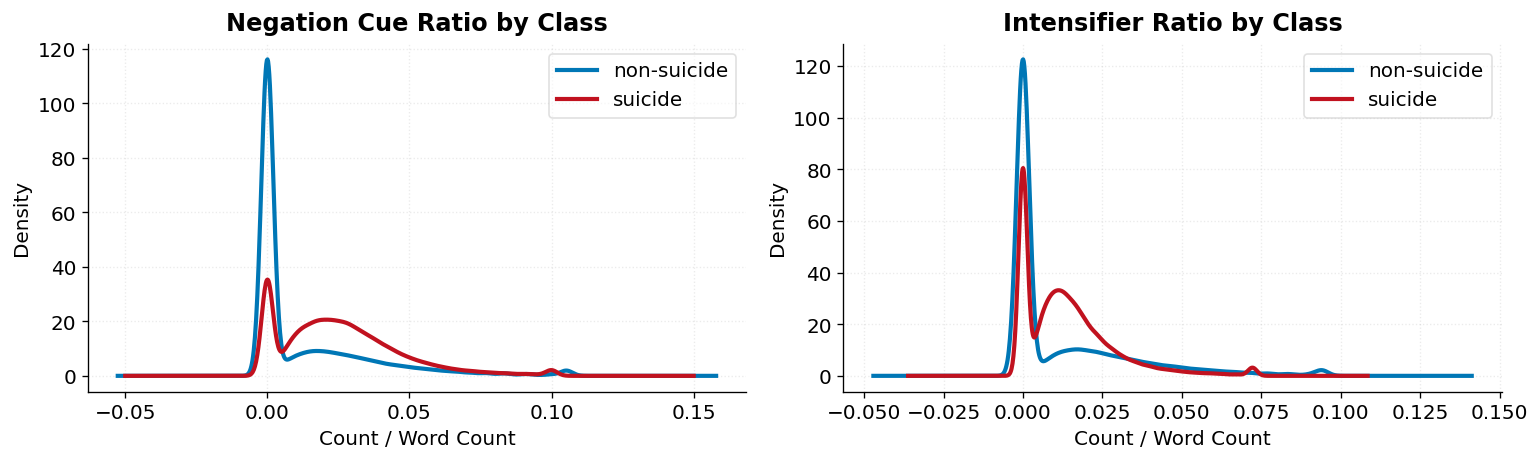

In [12]:
# Create subplots for linguistic signal distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Plot KDE distributions for each signal feature
for ax, col, title in zip(
    axes,
    ['neg_ratio', 'intens_ratio'],
    ['Negation Cue Ratio by Class', 'Intensifier Ratio by Class']
):
    for label, grp in df.groupby('label'):
        grp[col].clip(upper=grp[col].quantile(0.99)).plot.kde(
            ax=ax,
            label=label,
            color=CLASS_PALETTE[label],
            linewidth=2.5
        )
    ax.set_title(title, fontweight='bold', pad=8)
    ax.set_xlabel('Count / Word Count')
    ax.set_ylabel('Density')
    ax.legend(framealpha=0.6)

# Adjust layout and save figure
plt.tight_layout()
plt.savefig(EDA_DIR / 'linguistic_signal_distributions.png', bbox_inches='tight')
plt.show()

## Correlation Analysis of Numerical Features

This section examines relationships between numerical features and the target variable using a correlation matrix. The labels are first converted into binary form to enable inclusion in the analysis.

Pairwise correlations are computed across all selected features, allowing identification of potential dependencies and redundancies. A masked heatmap is used to present the lower triangle for clarity.

This analysis helps assess whether any features are strongly associated with the target or with each other, which can inform feature selection and modelling decisions.

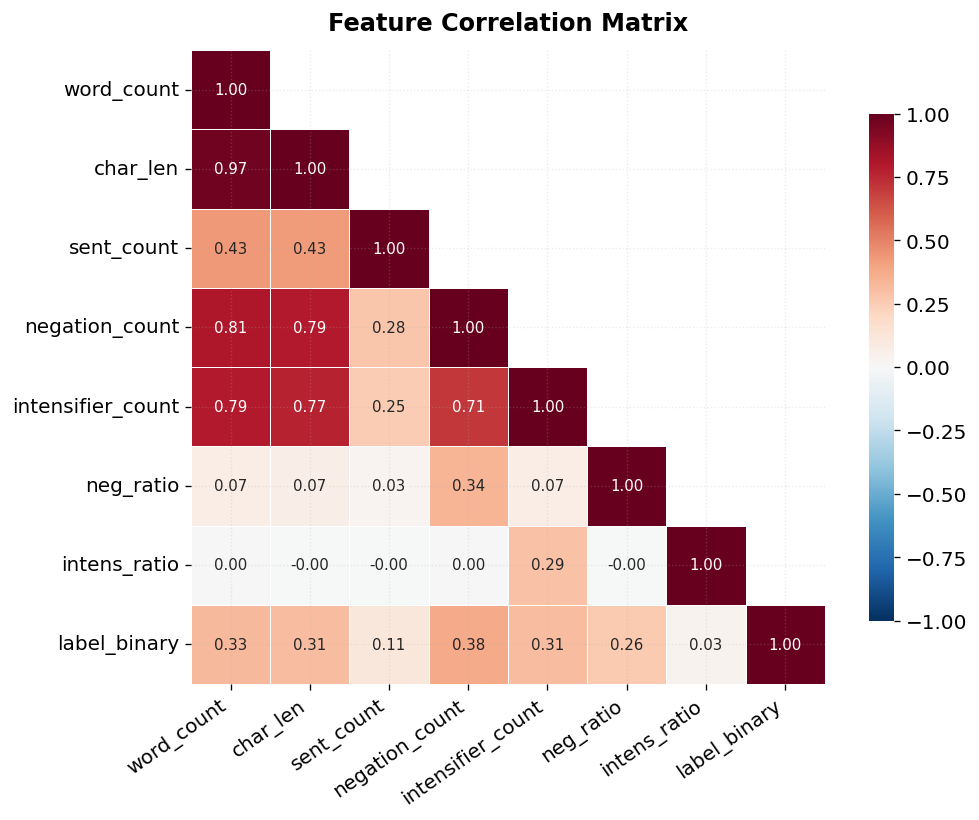

In [13]:
# Map labels to binary values for correlation analysis
df['label_binary'] = df['label'].map({'suicide': 1, 'non-suicide': 0})

# Select numerical features
num_cols = [
    'word_count', 'char_len', 'sent_count',
    'negation_count', 'intensifier_count',
    'neg_ratio', 'intens_ratio', 'label_binary'
]

# Compute correlation matrix
corr = df[num_cols].corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

# Plot heatmap
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    linewidths=0.4,
    square=True,
    annot_kws={'size': 9},
    cbar_kws={'shrink': 0.8}
)

# Rotate x-axis labels to 30 degrees for better readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# Set Heatmap Title
ax.set_title('Feature Correlation Matrix', fontweight='bold', pad=12)

# Adjust layout and save figure
plt.tight_layout()
plt.savefig(EDA_DIR / 'correlation_heatmap.png', bbox_inches='tight')
plt.show()